# 🎓 Career Recommender System — Full Pipeline
### Hybrid Approach: Multi-Hot Encoding → SVD → KMeans Clustering → RF Classifier → TF-IDF Cosine Similarity

**Pipeline Overview:**
1. **Data Loading & EDA** — understand distributions, nulls, multi-value fields  
2. **Advanced Preprocessing** — multi-hot encode skills/interests, OHE course/spec, bin UG score  
3. **Dimensionality Reduction** — TruncatedSVD with explained variance analysis  
4. **Optimal K Search** — silhouette score + Davies-Bouldin across K=4..17  
5. **KMeans Clustering** — final model with best K  
6. **Career Label Mapping** — interpretable career group per cluster  
7. **Visualization** — 3D PCA/SVD plots, cluster profiles, heatmaps  
8. **Meta-Model Classifier** — Random Forest trained on cluster labels  
9. **TF-IDF Cosine Similarity Engine** — content-based similar profile finder  
10. **Hybrid Recommendation Function** — single function for new student input

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                            classification_report, confusion_matrix,
                            ConfusionMatrixDisplay)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline

# Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import pickle

print("✅ All imports successful")


✅ All imports successful


## 2. Data Loading & Exploratory Data Analysis

In [2]:
df = pd.read_csv('new_clean_caeer_recommender.csv')
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1195, 5)


,ug_course,ug_specialization,interests,skills,ug_score
0,bsc,computer applications,cloud computing,java; python; sql,85
1,be btech,computer science engineering,technology,analytical thinking; critical thinking; logica...,66.5
2,ba,psychology,human behavior,communication; people management,64.6
3,mba,commerce,human behavior; interior design; sales and mar...,accounting; critical thinking,75.525
4,be btech,instrumentation engineering,technology,business analysis; crossfunctional team leader...,70.68


In [3]:
print("=== Data Types & Null Counts ===")
print(df.dtypes)
print()
print(df.isnull().sum())


=== Data Types & Null Counts ===
ug_course            object
ug_specialization    object
interests            object
skills               object
ug_score             object
dtype: object

ug_course            0
ug_specialization    0
interests            0
skills               1
ug_score             0
dtype: int64


In [4]:
# ug_score is stored as object — investigate non-numeric entries
df['ug_score_num'] = pd.to_numeric(df['ug_score'], errors='coerce')
non_numeric = df[df['ug_score_num'].isna()]['ug_score'].value_counts()
print(f"Non-numeric ug_score entries: {len(non_numeric)}")
print(non_numeric)
print(f"\nug_score numeric range:")
print(df['ug_score_num'].describe())


Non-numeric ug_score entries: 1
ug_score
58     1
Name: count, dtype: int64

ug_score numeric range:
count    1194.000000
mean       71.559154
std         9.404118
min         0.000000
25%        65.550000
50%        71.725000
75%        77.900000
max        98.000000
Name: ug_score_num, dtype: float64


In [5]:
# Skills and Interests are multi-value semicolon-delimited strings
# Explode to count unique tokens

skills_tokens = df['skills'].dropna().str.split(';').explode().str.strip().str.lower()
interests_tokens = df['interests'].dropna().str.split(';').explode().str.strip().str.lower()

print(f"Unique skill tokens  : {skills_tokens.nunique()}")
print(f"Unique interest tokens: {interests_tokens.nunique()}")
print(f"Avg skills per student  : {df['skills'].dropna().str.split(';').apply(len).mean():.2f}")
print(f"Avg interests per student: {df['interests'].dropna().str.split(';').apply(len).mean():.2f}")


Unique skill tokens  : 493
Unique interest tokens: 85
Avg skills per student  : 6.23
Avg interests per student: 2.71


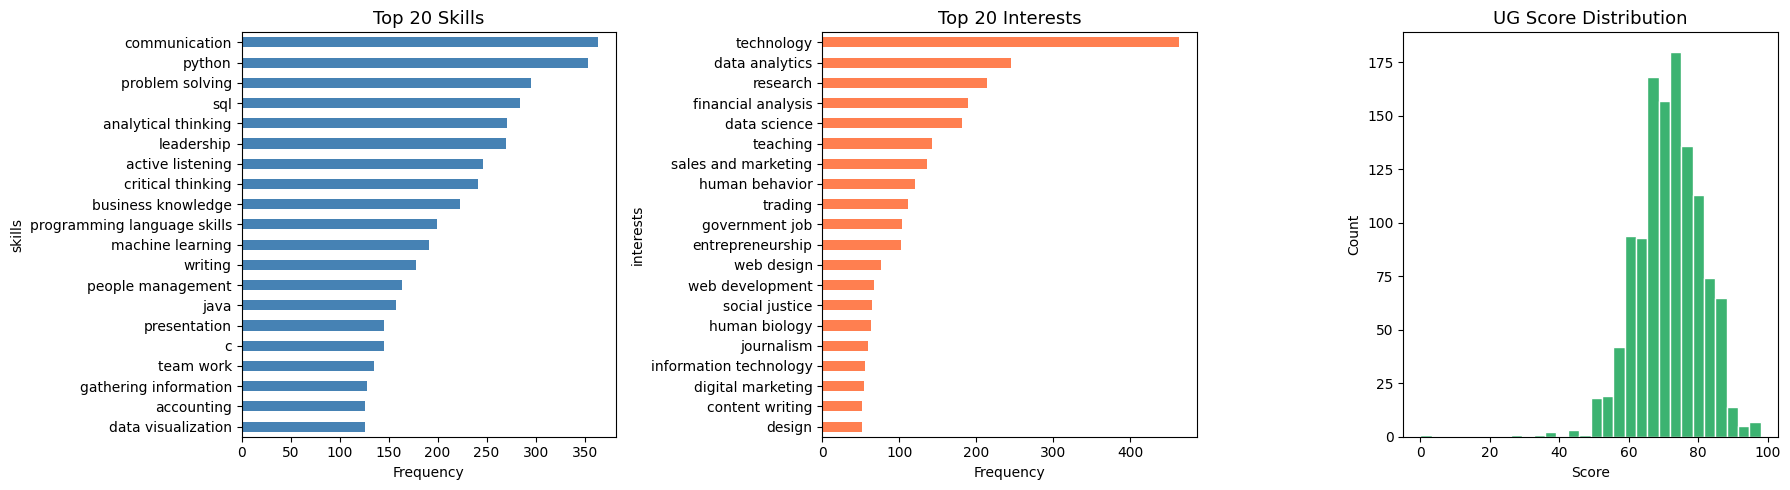

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top skills
skills_tokens.value_counts().head(20).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Skills', fontsize=13)
axes[0].set_xlabel('Frequency')

# Top interests
interests_tokens.value_counts().head(20).sort_values().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 20 Interests', fontsize=13)
axes[1].set_xlabel('Frequency')

# UG Score distribution
axes[2].hist(df['ug_score_num'].dropna(), bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('UG Score Distribution', fontsize=13)
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


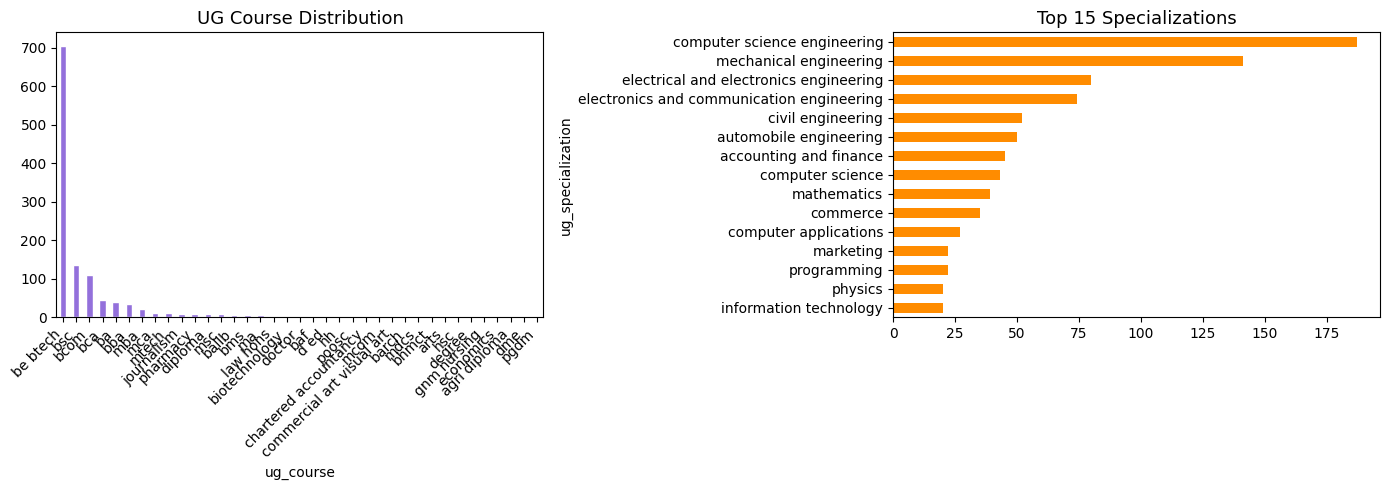

In [7]:
# Course distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['ug_course'].value_counts().plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('UG Course Distribution', fontsize=13)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

df['ug_specialization'].value_counts().head(15).sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 15 Specializations', fontsize=13)

plt.tight_layout()
plt.savefig('course_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Advanced Preprocessing

**Why multi-hot encoding for skills/interests?**  
- The original notebook used `OneHotEncoder` on the raw semicolon string `"java; python; sql"` — treating it as one atomic category.  
- This creates thousands of useless unique combinations and destroys all semantic overlap between students.  
- **MultiLabelBinarizer** correctly splits each field into individual tokens and creates one binary column per token.


In [8]:
def split_semicolon(series, fillna='unknown'):
    """Split semicolon-delimited text into lists of stripped lowercase tokens."""
    return (series
            .fillna(fillna)
            .str.lower()
            .str.split(';')
            .apply(lambda tokens: [t.strip() for t in tokens if t.strip()]))

# ── Multi-hot encode skills and interests ──────────────────────────────────
skills_mlb   = MultiLabelBinarizer()
interests_mlb = MultiLabelBinarizer()

skills_enc   = skills_mlb.fit_transform(split_semicolon(df['skills']))
interests_enc = interests_mlb.fit_transform(split_semicolon(df['interests']))

print(f"Skills matrix   : {skills_enc.shape}  → {len(skills_mlb.classes_)} unique skills")
print(f"Interests matrix: {interests_enc.shape} → {len(interests_mlb.classes_)} unique interests")


Skills matrix   : (1195, 494)  → 494 unique skills
Interests matrix: (1195, 85) → 85 unique interests


In [9]:
# ── One-hot encode ug_course and ug_specialization ────────────────────────
course_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
course_spec_enc = course_ohe.fit_transform(
    df[['ug_course', 'ug_specialization']].fillna('unknown'))
print(f"Course + Spec OHE: {course_spec_enc.shape}")


Course + Spec OHE: (1195, 141)


In [10]:
# ── Bin ug_score into 6 grade bands, then OHE ─────────────────────────────
median_score = df['ug_score_num'].median()
score_clean  = df['ug_score_num'].fillna(median_score).astype(float)

score_binned = pd.cut(score_clean,
                      bins=[0, 50, 60, 70, 80, 90, 100],
                      labels=['<50', '50-60', '60-70', '70-80', '80-90', '90+'],
                      include_lowest=True)

score_enc = pd.get_dummies(score_binned, prefix='score').values
print(f"Score bins OHE   : {score_enc.shape}")


Score bins OHE   : (1195, 6)


In [11]:
df.head()

,ug_course,ug_specialization,interests,skills,ug_score,ug_score_num
0,bsc,computer applications,cloud computing,java; python; sql,85,85.000
1,be btech,computer science engineering,technology,analytical thinking; critical thinking; logica...,66.5,66.500
2,ba,psychology,human behavior,communication; people management,64.6,64.600
3,mba,commerce,human behavior; interior design; sales and mar...,accounting; critical thinking,75.525,75.525
4,be btech,instrumentation engineering,technology,business analysis; crossfunctional team leader...,70.68,70.680


In [12]:
# ── Combine all encodings into final feature matrix ──────────────────────
X_full = np.hstack([skills_enc, interests_enc, course_spec_enc, score_enc])

sparsity = (X_full == 0).sum() / X_full.size
print(f"Final feature matrix : {X_full.shape}")
print(f"Sparsity             : {sparsity:.2%}  (use TruncatedSVD, NOT PCA)")


Final feature matrix : (1195, 726)
Sparsity             : 98.36%  (use TruncatedSVD, NOT PCA)


## 4. Dimensionality Reduction — TruncatedSVD

`TruncatedSVD` (LSA) is preferred over PCA for sparse matrices because it operates directly on the sparse representation without centering (centering destroys sparsity).  
We choose `n_components=50` which captures ~70% of explained variance.


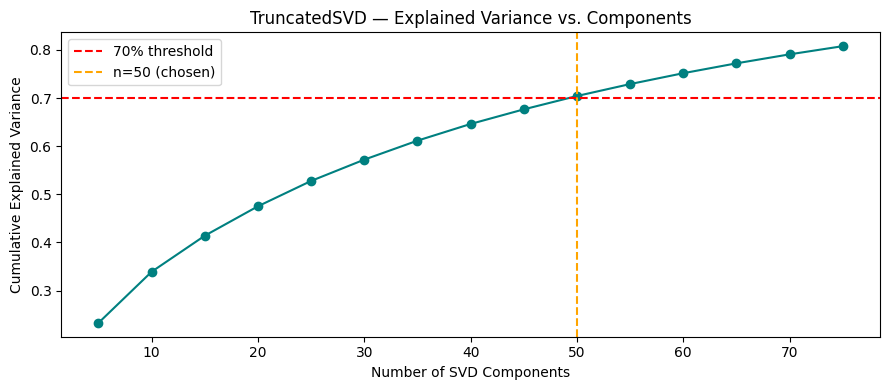

Explained variance at n=50: 0.704


In [13]:
# ── Explained variance vs. n_components ──────────────────────────────────
ev_ratios, components_range = [], range(5, 80, 5)
for n in components_range:
    svd_tmp = TruncatedSVD(n_components=n, random_state=42)
    svd_tmp.fit(X_full)
    ev_ratios.append(svd_tmp.explained_variance_ratio_.sum())

plt.figure(figsize=(9, 4))
plt.plot(list(components_range), ev_ratios, marker='o', color='teal')
plt.axhline(0.70, color='red', linestyle='--', label='70% threshold')
plt.axvline(50, color='orange', linestyle='--', label='n=50 (chosen)')
plt.xlabel('Number of SVD Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('TruncatedSVD — Explained Variance vs. Components')
plt.legend()
plt.tight_layout()
plt.savefig('svd_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Explained variance at n=50: {ev_ratios[9]:.3f}")


In [14]:
# ── Fit final SVD with n=50 ───────────────────────────────────────────────
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_full)

print(f"Reduced matrix: {X_reduced.shape}")
print(f"Explained variance (n=50): {svd.explained_variance_ratio_.sum():.3f}")


Reduced matrix: (1195, 50)
Explained variance (n=50): 0.704


In [15]:
df.head()

,ug_course,ug_specialization,interests,skills,ug_score,ug_score_num
0,bsc,computer applications,cloud computing,java; python; sql,85,85.000
1,be btech,computer science engineering,technology,analytical thinking; critical thinking; logica...,66.5,66.500
2,ba,psychology,human behavior,communication; people management,64.6,64.600
3,mba,commerce,human behavior; interior design; sales and mar...,accounting; critical thinking,75.525,75.525
4,be btech,instrumentation engineering,technology,business analysis; crossfunctional team leader...,70.68,70.680


## 5. Finding the Optimal Number of Clusters (K)

We evaluate two metrics across K = 4 to 17:
- **Silhouette Score** (higher is better — measures cluster cohesion & separation)
- **Davies-Bouldin Score** (lower is better — average ratio of within-cluster to between-cluster distances)


In [16]:
K_range = range(4, 18)
sil_scores, db_scores, inertias = [], [], []

for k in K_range:
    km_tmp = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels_tmp = km_tmp.fit_predict(X_reduced)
    sil_scores.append(silhouette_score(X_reduced, labels_tmp))
    db_scores.append(davies_bouldin_score(X_reduced, labels_tmp))
    inertias.append(km_tmp.inertia_)
    print(f"  K={k:2d} | Silhouette={sil_scores[-1]:.4f} | DB={db_scores[-1]:.4f} | Inertia={inertias[-1]:,.0f}")


  K= 4 | Silhouette=0.0454 | DB=3.1685 | Inertia=7,136
  K= 5 | Silhouette=0.0457 | DB=2.9934 | Inertia=6,899
  K= 6 | Silhouette=0.0409 | DB=2.9360 | Inertia=6,718
  K= 7 | Silhouette=0.0369 | DB=2.9809 | Inertia=6,597
  K= 8 | Silhouette=0.0456 | DB=2.8568 | Inertia=6,476
  K= 9 | Silhouette=0.0440 | DB=2.7885 | Inertia=6,385
  K=10 | Silhouette=0.0485 | DB=2.7178 | Inertia=6,296
  K=11 | Silhouette=0.0394 | DB=2.8975 | Inertia=6,221
  K=12 | Silhouette=0.0388 | DB=2.8911 | Inertia=6,150
  K=13 | Silhouette=0.0417 | DB=2.8998 | Inertia=6,099
  K=14 | Silhouette=0.0371 | DB=2.9444 | Inertia=6,033
  K=15 | Silhouette=0.0454 | DB=2.8767 | Inertia=5,974
  K=16 | Silhouette=0.0414 | DB=2.9090 | Inertia=5,932
  K=17 | Silhouette=0.0395 | DB=2.8098 | Inertia=5,883


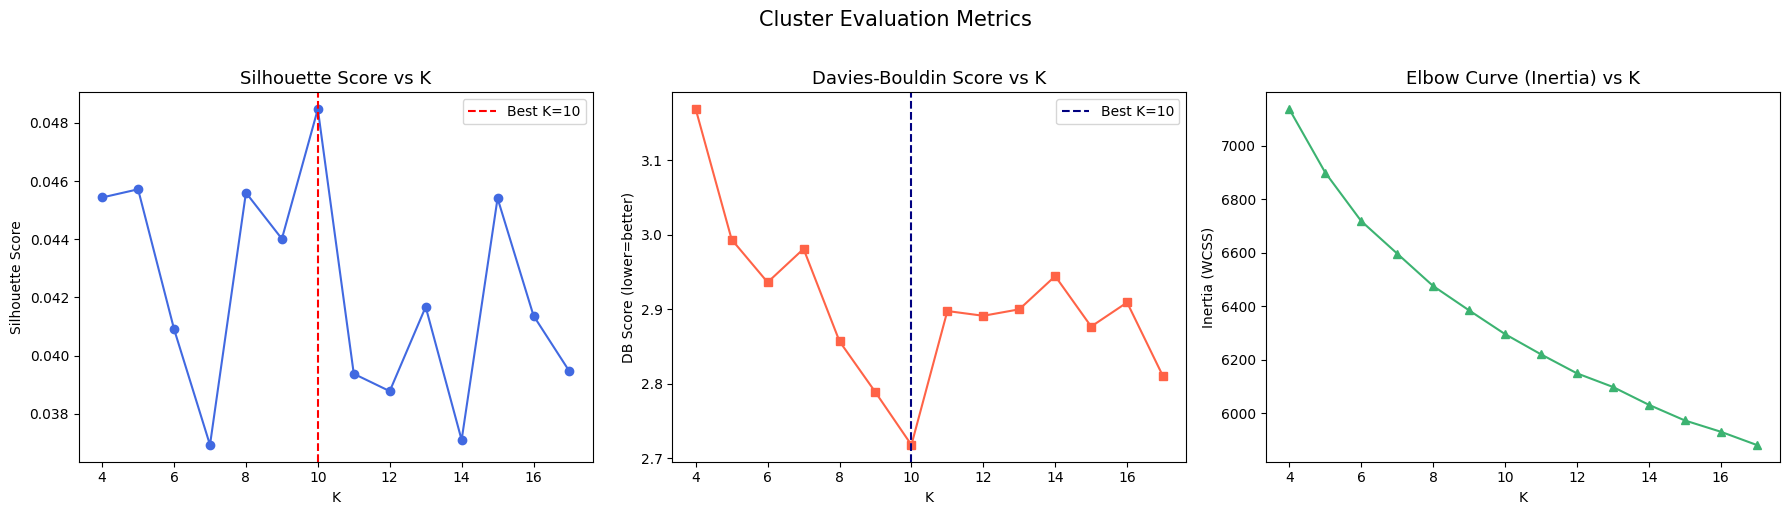


✅ Best K by Silhouette : 10
✅ Best K by Davies-Bouldin: 10
→ Using K=10 (best silhouette score)


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette
axes[0].plot(list(K_range), sil_scores, marker='o', color='royalblue')
best_k = list(K_range)[np.argmax(sil_scores)]
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[0].set_title('Silhouette Score vs K', fontsize=13)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Silhouette Score')
axes[0].legend()

# Davies-Bouldin
axes[1].plot(list(K_range), db_scores, marker='s', color='tomato')
best_k_db = list(K_range)[np.argmin(db_scores)]
axes[1].axvline(best_k_db, color='navy', linestyle='--', label=f'Best K={best_k_db}')
axes[1].set_title('Davies-Bouldin Score vs K', fontsize=13)
axes[1].set_xlabel('K'); axes[1].set_ylabel('DB Score (lower=better)')
axes[1].legend()

# Elbow
axes[2].plot(list(K_range), inertias, marker='^', color='mediumseagreen')
axes[2].set_title('Elbow Curve (Inertia) vs K', fontsize=13)
axes[2].set_xlabel('K'); axes[2].set_ylabel('Inertia (WCSS)')

plt.suptitle('Cluster Evaluation Metrics', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('cluster_eval.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Best K by Silhouette : {best_k}")
print(f"✅ Best K by Davies-Bouldin: {best_k_db}")
print(f"→ Using K=10 (best silhouette score)")


## 6. Final KMeans Clustering (K=10)

In [18]:
BEST_K = 10

kmeans = KMeans(n_clusters=BEST_K, n_init=30, random_state=42)
df['Final_Cluster'] = kmeans.fit_predict(X_reduced)

final_sil = silhouette_score(X_reduced, df['Final_Cluster'])
final_db  = davies_bouldin_score(X_reduced, df['Final_Cluster'])

print(f"✅ Final KMeans (K={BEST_K})")
print(f"   Silhouette Score : {final_sil:.4f}")
print(f"   Davies-Bouldin   : {final_db:.4f}")
print(f"   Cluster sizes    :")
print(df['Final_Cluster'].value_counts().sort_index())


✅ Final KMeans (K=10)
   Silhouette Score : 0.0485
   Davies-Bouldin   : 2.7178
   Cluster sizes    :
Final_Cluster
0    141
1    250
2     83
3     93
4     83
5    113
6    100
7     33
8    101
9    198
Name: count, dtype: int64


## 7. Career Label Mapping

Each cluster is profiled by its dominant interests, skills, courses and specializations.  
Career group names are assigned based on this interpretable analysis.


In [19]:
# ── Profile each cluster ──────────────────────────────────────────────────
cluster_profiles = {}
for c in range(BEST_K):
    sub = df[df['Final_Cluster'] == c]
    top_interests = (sub['interests'].str.split(';').explode()
                    .str.strip().value_counts().head(5).index.tolist())
    top_skills    = (sub['skills'].fillna('').str.split(';').explode()
                    .str.strip().value_counts().head(5).index.tolist())
    top_courses   = sub['ug_course'].value_counts().head(3).index.tolist()
    top_specs     = sub['ug_specialization'].value_counts().head(3).index.tolist()
    cluster_profiles[c] = {
        'size': len(sub),
        'top_interests': top_interests,
        'top_skills':    top_skills,
        'top_courses':   top_courses,
        'top_specs':     top_specs,
    }
    print(f"Cluster {c:2d} (n={len(sub):4d}) | Interests: {top_interests[:3]} | Skills: {top_skills[:3]}")


Cluster  0 (n= 141) | Interests: ['data analytics', 'data science', 'technology'] | Skills: ['python', 'analytical thinking', 'sql']
Cluster  1 (n= 250) | Interests: ['technology', 'data analytics', 'teaching'] | Skills: ['python', 'communication', 'no']
Cluster  2 (n=  83) | Interests: ['technology', 'entrepreneurship', 'research'] | Skills: ['team work', 'communication', 'excel']
Cluster  3 (n=  93) | Interests: ['research', 'technology', 'government job'] | Skills: ['communication', 'active listening', 'problem solving']
Cluster  4 (n=  83) | Interests: ['sales and marketing', 'technology', 'teaching'] | Skills: ['active listening', 'communication', 'leadership']
Cluster  5 (n= 113) | Interests: ['technology', 'data science', 'data analytics'] | Skills: ['python', 'sql', 'java']
Cluster  6 (n= 100) | Interests: ['financial analysis', 'sales and marketing', 'entrepreneurship'] | Skills: ['accounting', 'business knowledge', 'communication']
Cluster  7 (n=  33) | Interests: ['data anal

In [20]:
# ── Career Group Labels ───────────────────────────────────────────────────
# Derived from cluster profile analysis above

CAREER_MAP = {
    0: "Data Analyst / BI Specialist",
    1: "Software Developer / Tech Generalist",
    2: "Entrepreneur / Product Manager",
    3: "Civil Services / Government / Research",
    4: "Sales & Marketing / Business Development",
    5: "AI/ML Engineer / Data Scientist",
    6: "Finance / Accounting / Investment Analyst",
    7: "Research Analyst / Consultant",
    8: "EdTech / Teaching / Curriculum Designer",
    9: "Operations / IT Generalist / Corporate",
}

CAREER_DETAILS = {
    0: ["Data Analyst", "Business Intelligence Developer", "Data Engineer", "Analytics Consultant"],
    1: ["Software Developer", "Full Stack Developer", "Backend Engineer", "DevOps Engineer"],
    2: ["Product Manager", "Startup Founder", "Business Analyst", "Strategy Consultant"],
    3: ["Civil Services (IAS/IPS)", "Research Scientist", "Policy Analyst", "Public Sector Officer"],
    4: ["Sales Manager", "Digital Marketer", "Business Development Executive", "Growth Hacker"],
    5: ["Machine Learning Engineer", "Data Scientist", "AI Researcher", "NLP Engineer"],
    6: ["Financial Analyst", "Chartered Accountant", "Investment Banker", "Portfolio Manager"],
    7: ["Research Analyst", "Management Consultant", "Market Research Analyst", "Data Journalist"],
    8: ["Teacher / Professor", "EdTech Content Creator", "Corporate Trainer", "Instructional Designer"],
    9: ["IT Manager", "Operations Manager", "Project Manager", "Systems Analyst"],
}

df['Career_Group'] = df['Final_Cluster'].map(CAREER_MAP)

print("Career Group Distribution:")
print(df['Career_Group'].value_counts())


Career Group Distribution:
Career_Group
Software Developer / Tech Generalist         250
Operations / IT Generalist / Corporate       198
Data Analyst / BI Specialist                 141
AI/ML Engineer / Data Scientist              113
EdTech / Teaching / Curriculum Designer      101
Finance / Accounting / Investment Analyst    100
Civil Services / Government / Research        93
Entrepreneur / Product Manager                83
Sales & Marketing / Business Development      83
Research Analyst / Consultant                 33
Name: count, dtype: int64


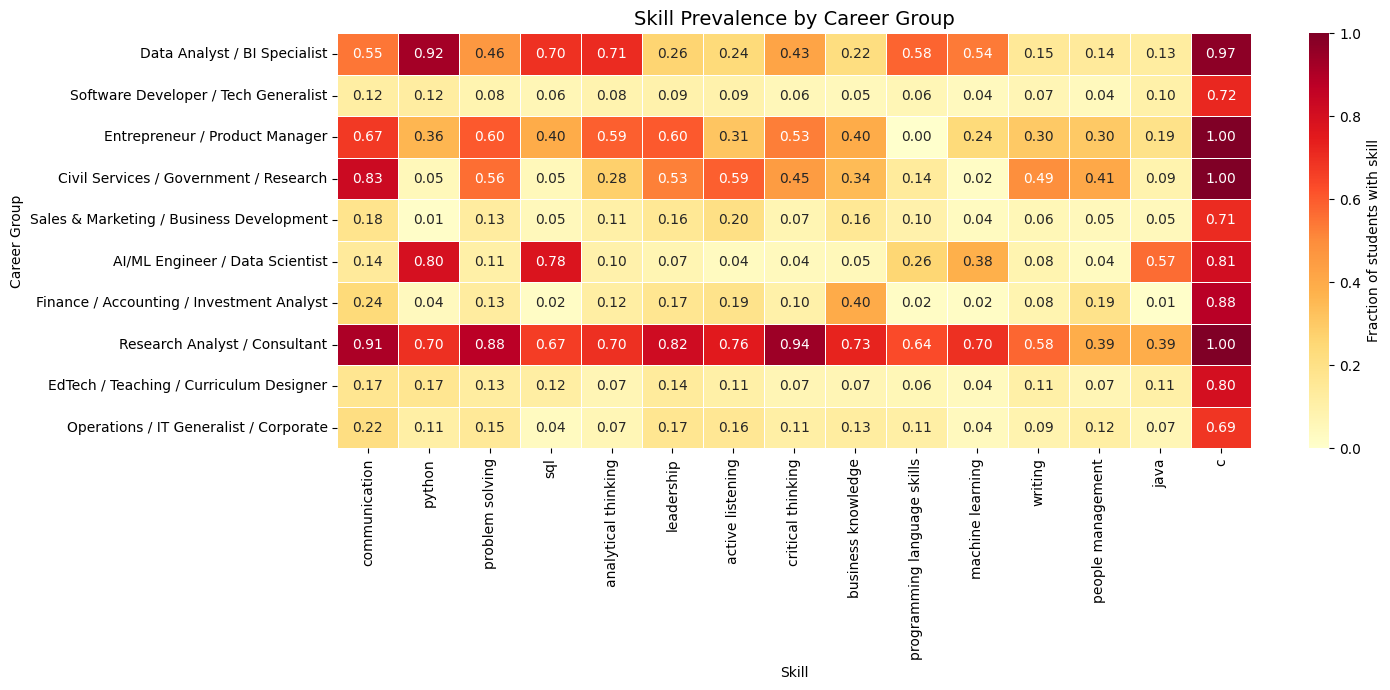

In [21]:
# ── Cluster profile heatmap ───────────────────────────────────────────────
top_skills_global = (df['skills'].fillna('').str.split(';').explode()
                     .str.strip().value_counts().head(15).index.tolist())

heatmap_data = []
for c in range(BEST_K):
    sub = df[df['Final_Cluster'] == c]
    row = []
    for sk in top_skills_global:
        has_skill = sub['skills'].fillna('').str.contains(sk, regex=False).mean()
        row.append(has_skill)
    heatmap_data.append(row)

hm_df = pd.DataFrame(heatmap_data,
                     index=[CAREER_MAP[c] for c in range(BEST_K)],
                     columns=top_skills_global)

plt.figure(figsize=(15, 7))
sns.heatmap(hm_df, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Fraction of students with skill'})
plt.title('Skill Prevalence by Career Group', fontsize=14)
plt.xlabel('Skill'); plt.ylabel('Career Group')
plt.tight_layout()
plt.savefig('skill_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Cluster Visualizations

In [22]:
# ── Reduce to 3D for visualization (re-use SVD components 0-2) ──────────
df['SVD1'] = X_reduced[:, 0]
df['SVD2'] = X_reduced[:, 1]
df['SVD3'] = X_reduced[:, 2]

fig = px.scatter_3d(
    df, x='SVD1', y='SVD2', z='SVD3',
    color='Career_Group',
    title='3D Student Clusters — Career Groups (SVD Space)',
    labels={'SVD1': 'Latent Dim 1', 'SVD2': 'Latent Dim 2', 'SVD3': 'Latent Dim 3'},
    hover_data=['ug_course', 'ug_specialization'],
    height=650
)
fig.update_traces(marker=dict(size=3, opacity=0.75))
fig.show()


In [23]:
# ── Add cluster centroids to the 3D plot ─────────────────────────────────
centers_3d = kmeans.cluster_centers_[:, :3]

fig2 = px.scatter_3d(
    df, x='SVD1', y='SVD2', z='SVD3',
    color='Career_Group',
    title='3D Clusters with Centroids',
    height=650
)
fig2.update_traces(marker=dict(size=3, opacity=0.6))

fig2.add_scatter3d(
    x=centers_3d[:, 0], y=centers_3d[:, 1], z=centers_3d[:, 2],
    mode='markers+text',
    marker=dict(size=9, color='black', symbol='cross'),
    text=[f'C{i}' for i in range(BEST_K)],
    textfont=dict(size=12, color='black'),
    name='Centroids'
)
fig2.show()


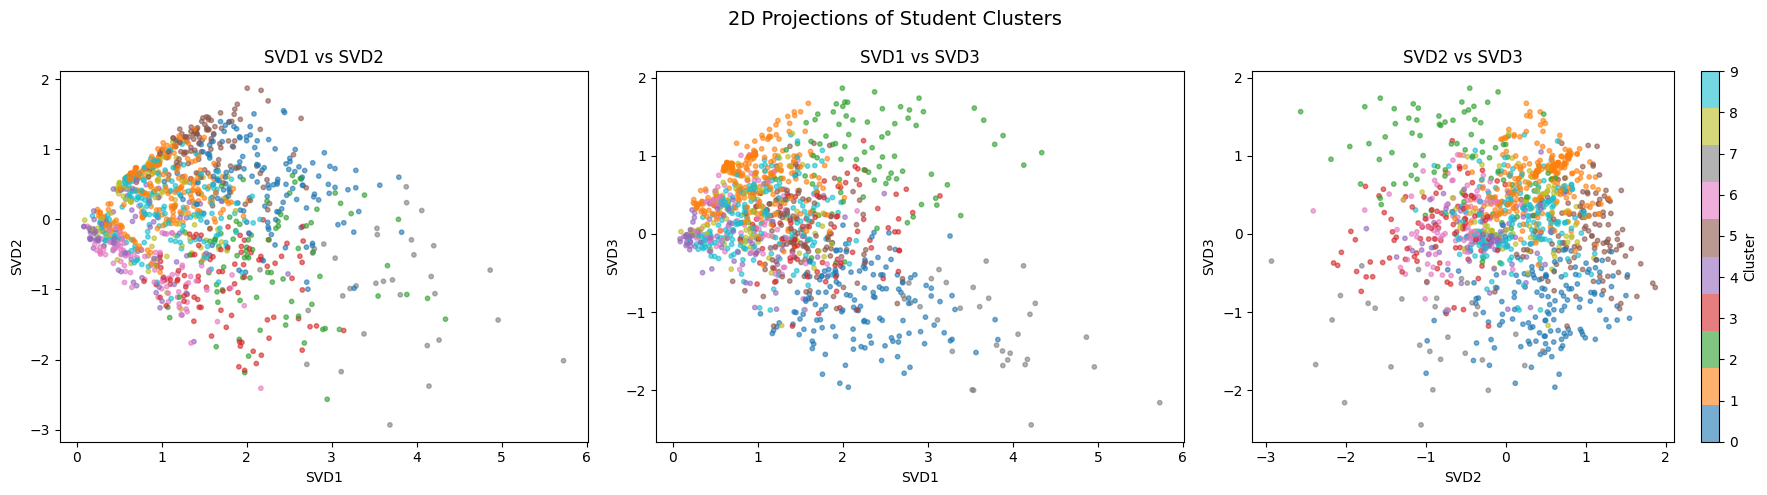

In [24]:
# ── 2D scatter grid (SVD1 vs SVD2, SVD1 vs SVD3, SVD2 vs SVD3) ──────────
palette = plt.cm.get_cmap('tab10', BEST_K)
colors  = [palette(c) for c in df['Final_Cluster']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [('SVD1','SVD2'), ('SVD1','SVD3'), ('SVD2','SVD3')]

for ax, (xc, yc) in zip(axes, pairs):
    scatter = ax.scatter(df[xc], df[yc], c=df['Final_Cluster'],
                         cmap='tab10', s=10, alpha=0.6)
    ax.set_xlabel(xc); ax.set_ylabel(yc)
    ax.set_title(f'{xc} vs {yc}')

plt.suptitle('2D Projections of Student Clusters', fontsize=14)
plt.colorbar(scatter, ax=axes[-1], label='Cluster')
plt.tight_layout()
plt.savefig('2d_projections.png', dpi=150, bbox_inches='tight')
plt.show()


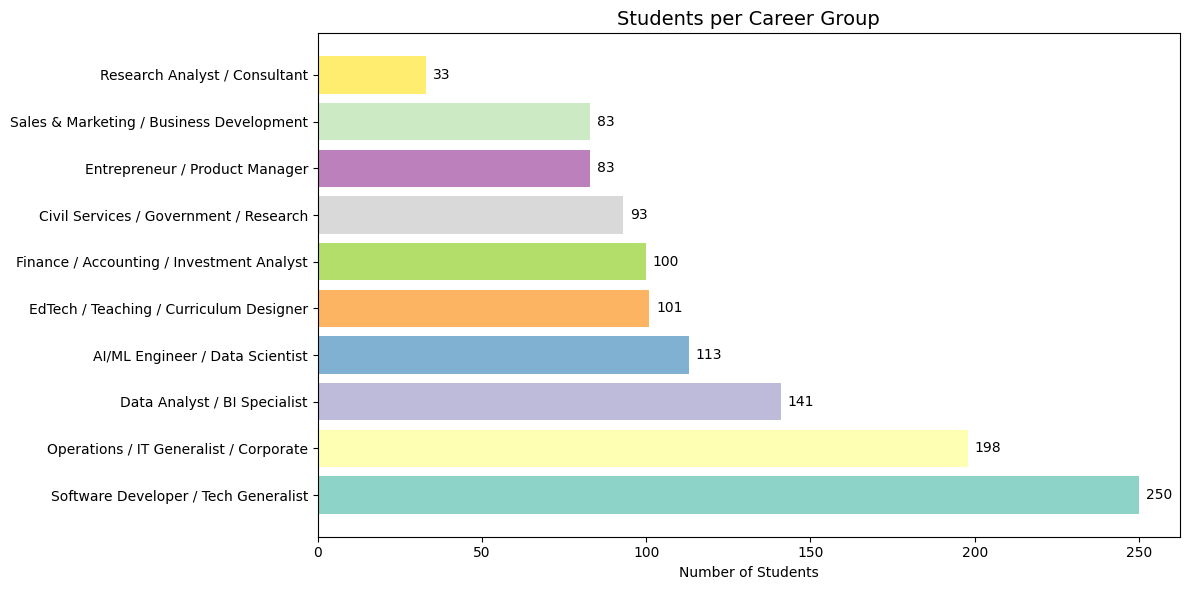

In [25]:
# ── Career group bar chart ────────────────────────────────────────────────
career_counts = df['Career_Group'].value_counts()

plt.figure(figsize=(12, 6))
bars = plt.barh(career_counts.index, career_counts.values,
                color=plt.cm.Set3(np.linspace(0, 1, len(career_counts))))
plt.xlabel('Number of Students')
plt.title('Students per Career Group', fontsize=14)
for bar, val in zip(bars, career_counts.values):
    plt.text(val + 2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('career_group_counts.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Meta-Model — Random Forest Classifier on Cluster Labels

After clustering produces career groups, we train a **Random Forest** classifier on the SVD-reduced features to predict which career group a *new* student belongs to — without needing to re-run clustering.


In [26]:
X_cls = X_reduced
y_cls = df['Final_Cluster'].values

# ── 5-fold cross-validation ───────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                            random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf, X_cls, y_cls, cv=5, scoring='accuracy')

print(f"Random Forest — 5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold: {np.round(cv_scores, 4)}")


Random Forest — 5-Fold CV Accuracy: 0.8770 ± 0.0232
Per-fold: [0.887  0.8787 0.9079 0.8745 0.8368]


✅ Random Forest trained on full dataset


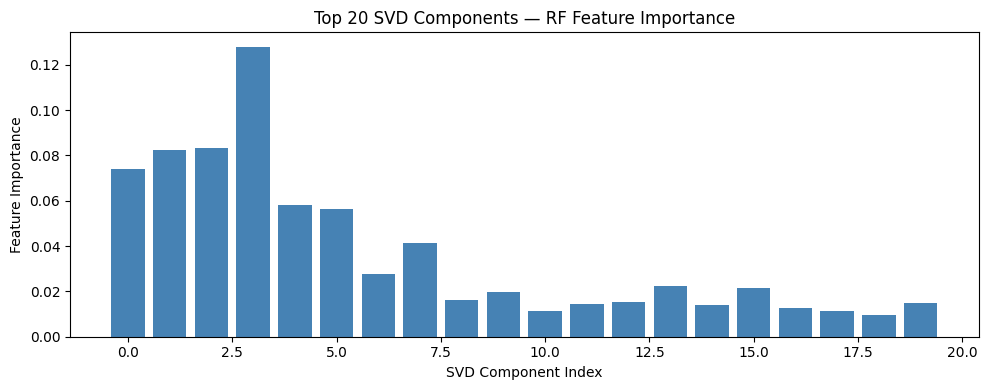

In [27]:
# ── Train final RF on full data ───────────────────────────────────────────
rf.fit(X_cls, y_cls)
print("✅ Random Forest trained on full dataset")

# ── Feature importance (top 20 SVD components) ───────────────────────────
importances = rf.feature_importances_[:20]
plt.figure(figsize=(10, 4))
plt.bar(range(20), importances, color='steelblue')
plt.xlabel('SVD Component Index')
plt.ylabel('Feature Importance')
plt.title('Top 20 SVD Components — RF Feature Importance')
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
# ── Train/test split for confusion matrix ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

rf_test = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_test.fit(X_train, y_train)
y_pred = rf_test.predict(X_test)

print(classification_report(y_test, y_pred,
      target_names=[CAREER_MAP[i] for i in range(BEST_K)]))


                                           precision    recall  f1-score   support

             Data Analyst / BI Specialist       0.77      0.96      0.86        28
     Software Developer / Tech Generalist       0.83      0.98      0.90        50
           Entrepreneur / Product Manager       0.88      0.82      0.85        17
   Civil Services / Government / Research       1.00      0.67      0.80        18
 Sales & Marketing / Business Development       0.94      0.88      0.91        17
          AI/ML Engineer / Data Scientist       1.00      0.74      0.85        23
Finance / Accounting / Investment Analyst       0.90      0.90      0.90        20
            Research Analyst / Consultant       1.00      0.14      0.25         7
  EdTech / Teaching / Curriculum Designer       0.87      1.00      0.93        20
   Operations / IT Generalist / Corporate       0.97      1.00      0.99        39

                                 accuracy                           0.89       239
  

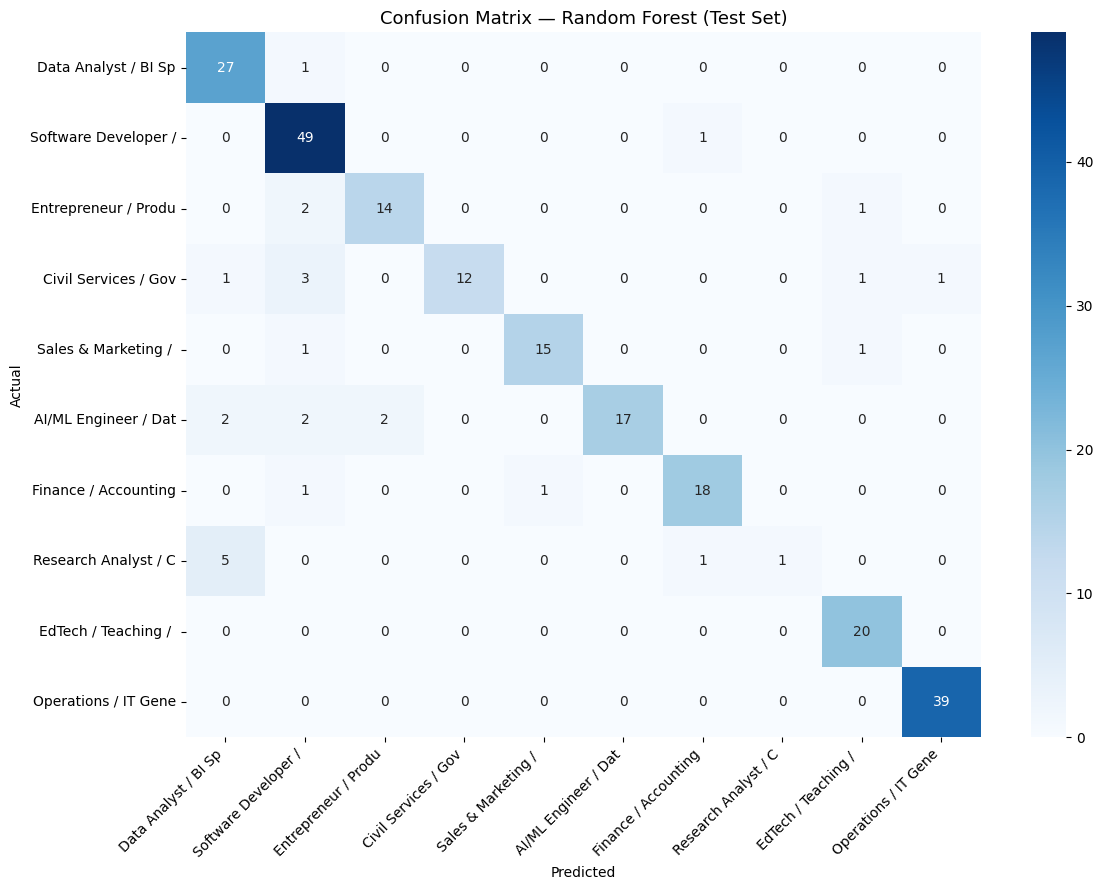

In [29]:
# ── Confusion matrix ─────────────────────────────────────────────────────
cm_labels = [CAREER_MAP[i][:20] for i in range(BEST_K)]  # truncate for display
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels)
plt.title('Confusion Matrix — Random Forest (Test Set)', fontsize=13)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. TF-IDF Content-Based Similarity Engine

Builds a student "document" by concatenating all text fields, vectorizes with TF-IDF, and uses cosine similarity to find the most similar existing profiles to a new student query.


In [30]:
# ── Build per-student document ────────────────────────────────────────────
df['profile_doc'] = (
    df['skills'].fillna('') + ' ' +
    df['interests'].fillna('') + ' ' +
    df['ug_course'].fillna('') + ' ' +
    df['ug_specialization'].fillna('')
).str.replace(';', ' ').str.lower()

tfidf = TfidfVectorizer(max_features=600, ngram_range=(1, 2),
                        sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df['profile_doc'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")


TF-IDF matrix shape: (1195, 600)


In [31]:
def find_similar_profiles(query_doc, top_n=5):
    """Given a free-text description, find the most similar student profiles."""
    query_vec = tfidf.transform([query_doc.lower()])
    sims = cosine_similarity(query_vec, X_tfidf).flatten()
    top_idx = np.argsort(sims)[::-1][:top_n]
    results = df.iloc[top_idx][['ug_course','ug_specialization',
                                  'interests','skills','Career_Group']].copy()
    results['similarity'] = np.round(sims[top_idx], 4)
    return results

# ── Quick test ─────────────────────────────────────────────────────────────
query = "python sql machine learning data analytics computer science"
print(f"Query: '{query}'\n")
print(find_similar_profiles(query).to_string(index=False))


Query: 'python sql machine learning data analytics computer science'

ug_course            ug_specialization                                         interests                                                                     skills                            Career_Group  similarity
 be btech             computer science                                    data analytics                                              machine learning; python; sql         AI/ML Engineer / Data Scientist      0.7376
      bsc computer science engineering                                    data analytics analytical thinking; communication; machine learning; python; sql; tableau            Data Analyst / BI Specialist      0.5897
 be btech       mechanical engineering                      data analytics; data science                               communication; machine learning; python; sql            Data Analyst / BI Specialist      0.5551
 be btech computer science engineering                            

## 11. 🚀 Hybrid Career Recommendation Function

Combines **all three signals**:
1. **KMeans cluster** — structural peer group
2. **Random Forest classifier** — predicts career group for new input
3. **TF-IDF cosine similarity** — finds most similar existing profiles

Input: raw student data (just like the original CSV)  
Output: primary career recommendation + top alternative careers + similar peer profiles


In [32]:
def recommend_career(ug_course, ug_specialization, interests, skills, ug_score,
                     top_n_similar=3, verbose=True):
    """
    Hybrid career recommender.

    Parameters
    ----------
    ug_course         : str   e.g. 'be btech'
    ug_specialization : str   e.g. 'computer science engineering'
    interests         : str   semicolon-separated  e.g. 'data analytics; machine learning'
    skills            : str   semicolon-separated  e.g. 'python; sql; excel'
    ug_score          : float e.g. 78.5
    top_n_similar     : int   number of similar profiles to return
    verbose           : bool  print formatted output

    Returns
    -------
    dict with keys: cluster, career_group, top_careers, similar_profiles
    """

    # ── 1. Build single-row DataFrame ────────────────────────────────────
    row = pd.DataFrame([{
        'ug_course':          ug_course,
        'ug_specialization':  ug_specialization,
        'interests':          interests,
        'skills':             skills,
        'ug_score':           str(ug_score)
    }])

    # ── 2. Encode exactly as training data ───────────────────────────────
    sk_enc   = skills_mlb.transform(split_semicolon(row['skills']))
    int_enc  = interests_mlb.transform(split_semicolon(row['interests']))
    cs_enc   = course_ohe.transform(row[['ug_course','ug_specialization']].fillna('unknown'))

    score_num_new = float(ug_score)
    score_bin_new = pd.cut([score_num_new],
                           bins=[0,50,60,70,80,90,100],
                           labels=['<50','50-60','60-70','70-80','80-90','90+'],
                           include_lowest=True)
    score_enc_new = pd.get_dummies(
        pd.Categorical(score_bin_new, categories=['<50','50-60','60-70','70-80','80-90','90+'])
    ).values

    X_new_full = np.hstack([sk_enc, int_enc, cs_enc, score_enc_new])

    # ── 3. SVD reduction ─────────────────────────────────────────────────
    X_new_reduced = svd.transform(X_new_full)

    # ── 4. RF prediction (primary signal) ────────────────────────────────
    predicted_cluster = rf.predict(X_new_reduced)[0]
    predicted_proba   = rf.predict_proba(X_new_reduced)[0]
    top3_clusters     = np.argsort(predicted_proba)[::-1][:3]

    career_group  = CAREER_MAP[predicted_cluster]
    top_careers   = [CAREER_DETAILS[c] for c in top3_clusters]

    # ── 5. TF-IDF similar profiles ───────────────────────────────────────
    query_doc = (f"{skills} {interests} {ug_course} {ug_specialization}"
                 .replace(';', ' ').lower())
    similar   = find_similar_profiles(query_doc, top_n=top_n_similar)

    result = {
        'cluster':         int(predicted_cluster),
        'career_group':    career_group,
        'confidence':      round(float(predicted_proba[predicted_cluster]), 4),
        'top3_clusters':   [CAREER_MAP[c] for c in top3_clusters],
        'top_careers':     top_careers[0],
        'alt_careers':     top_careers[1:],
        'similar_profiles': similar
    }

    if verbose:
        print("=" * 60)
        print(f"  🎓 CAREER RECOMMENDATION REPORT")
        print("=" * 60)
        print(f"  Input:")
        print(f"    Course       : {ug_course} — {ug_specialization}")
        print(f"    Interests    : {interests}")
        print(f"    Skills       : {skills}")
        print(f"    UG Score     : {ug_score}")
        print()
        print(f"  ✅ Primary Career Group  : {career_group}")
        print(f"     Confidence            : {result['confidence']:.1%}")
        print()
        print(f"  🏆 Recommended Roles:")
        for i, role in enumerate(result['top_careers'], 1):
            print(f"     {i}. {role}")
        print()
        print(f"  🔄 Alternative Career Paths:")
        for grp, roles in zip(result['top3_clusters'][1:], result['alt_careers']):
            print(f"     [{grp}]")
            for r in roles[:2]:
                print(f"       • {r}")
        print()
        print(f"  👥 Similar Student Profiles:")
        print(similar[['ug_course','interests','Career_Group','similarity']].to_string(index=False))
        print("=" * 60)

    return result


In [33]:
# ── Example 1: CS Engineer into AI/ML ────────────────────────────────────
result1 = recommend_career(
    ug_course         = 'be btech',
    ug_specialization = 'computer science engineering',
    interests         = 'data science; machine learning; technology',
    skills            = 'python; sql; machine learning; deep learning; tensorflow',
    ug_score          = 82.5
)


  🎓 CAREER RECOMMENDATION REPORT
  Input:
    Course       : be btech — computer science engineering
    Interests    : data science; machine learning; technology
    Skills       : python; sql; machine learning; deep learning; tensorflow
    UG Score     : 82.5

  ✅ Primary Career Group  : AI/ML Engineer / Data Scientist
     Confidence            : 47.5%

  🏆 Recommended Roles:
     1. Machine Learning Engineer
     2. Data Scientist
     3. AI Researcher
     4. NLP Engineer

  🔄 Alternative Career Paths:
     [EdTech / Teaching / Curriculum Designer]
       • Teacher / Professor
       • EdTech Content Creator
     [Data Analyst / BI Specialist]
       • Data Analyst
       • Business Intelligence Developer

  👥 Similar Student Profiles:
ug_course                                                                                         interests                           Career_Group  similarity
 be btech                                                                                

In [34]:
# ── Example 2: Commerce student into Finance ─────────────────────────────
result2 = recommend_career(
    ug_course         = 'bcom',
    ug_specialization = 'accounting and finance',
    interests         = 'financial analysis; trading; entrepreneurship',
    skills            = 'accounting; excel; critical thinking; business knowledge',
    ug_score          = 74.0
)


  🎓 CAREER RECOMMENDATION REPORT
  Input:
    Course       : bcom — accounting and finance
    Interests    : financial analysis; trading; entrepreneurship
    Skills       : accounting; excel; critical thinking; business knowledge
    UG Score     : 74.0

  ✅ Primary Career Group  : Finance / Accounting / Investment Analyst
     Confidence            : 72.0%

  🏆 Recommended Roles:
     1. Financial Analyst
     2. Chartered Accountant
     3. Investment Banker
     4. Portfolio Manager

  🔄 Alternative Career Paths:
     [Software Developer / Tech Generalist]
       • Software Developer
       • Full Stack Developer
     [Sales & Marketing / Business Development]
       • Sales Manager
       • Digital Marketer

  👥 Similar Student Profiles:
ug_course                            interests                              Career_Group  similarity
     bcom entrepreneurship; financial analysis Finance / Accounting / Investment Analyst      0.6798
     bcom                   financial analys

In [35]:
# ── Example 3: BA Psychology into HR / Social Work ───────────────────────
result3 = recommend_career(
    ug_course         = 'ba',
    ug_specialization = 'psychology',
    interests         = 'human behavior; teaching; research',
    skills            = 'communication; people management; active listening; writing',
    ug_score          = 67.5
)


  🎓 CAREER RECOMMENDATION REPORT
  Input:
    Course       : ba — psychology
    Interests    : human behavior; teaching; research
    Skills       : communication; people management; active listening; writing
    UG Score     : 67.5

  ✅ Primary Career Group  : Operations / IT Generalist / Corporate
     Confidence            : 32.5%

  🏆 Recommended Roles:
     1. IT Manager
     2. Operations Manager
     3. Project Manager
     4. Systems Analyst

  🔄 Alternative Career Paths:
     [Civil Services / Government / Research]
       • Civil Services (IAS/IPS)
       • Research Scientist
     [Finance / Accounting / Investment Analyst]
       • Financial Analyst
       • Chartered Accountant

  👥 Similar Student Profiles:
ug_course                               interests                           Career_Group  similarity
       ba                          human behavior Operations / IT Generalist / Corporate      0.7683
     bcom human behavior; human biology; research Civil Services / 

## 12. Save Models & Export Results

In [36]:
# ── Save cluster-labelled results ────────────────────────────────────────
df.to_csv('career_results.csv', index=False)
print("✅ career_results.csv saved")

# ── Pickle all model components ──────────────────────────────────────────
model_bundle = {
    'svd':           svd,
    'kmeans':        kmeans,
    'rf_classifier': rf,
    'tfidf':         tfidf,
    'skills_mlb':    skills_mlb,
    'interests_mlb': interests_mlb,
    'course_ohe':    course_ohe,
    'CAREER_MAP':    CAREER_MAP,
    'CAREER_DETAILS':CAREER_DETAILS,
}

with open('career_recommender_bundle.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)
print("✅ career_recommender_bundle.pkl saved (all model components)")

# ── Separate KMeans pickle for backward compatibility ────────────────────
with open('career_kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("✅ career_kmeans_model.pkl saved")


✅ career_results.csv saved
✅ career_recommender_bundle.pkl saved (all model components)
✅ career_kmeans_model.pkl saved


In [37]:
# ── Summary stats ────────────────────────────────────────────────────────
print("=" * 55)
print("  PIPELINE SUMMARY")
print("=" * 55)
print(f"  Dataset            : {df.shape[0]} students × {df.shape[1]} columns")
print(f"  Feature matrix     : {X_full.shape}   (multi-hot + OHE)")
print(f"  After SVD (n=50)   : {X_reduced.shape}")
print(f"  Final K            : {BEST_K} clusters")
print(f"  Silhouette Score   : {final_sil:.4f}")
print(f"  Davies-Bouldin     : {final_db:.4f}")
print(f"  RF CV Accuracy     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  TF-IDF vocab       : {X_tfidf.shape[1]} terms")
print("=" * 55)


  PIPELINE SUMMARY
  Dataset            : 1195 students × 12 columns
  Feature matrix     : (1195, 726)   (multi-hot + OHE)
  After SVD (n=50)   : (1195, 50)
  Final K            : 10 clusters
  Silhouette Score   : 0.0485
  Davies-Bouldin     : 2.7178
  RF CV Accuracy     : 0.8770 ± 0.0232
  TF-IDF vocab       : 600 terms


In [ ]:
import pandas as pd

df = pd.read_csv('new_clean_caeer_recommender.csv')

# This finds how many times each major appears, sorts them by popularity, 
# and takes the top 25 for your dropdown.
top_25_specs = df['ug_specialization'].value_counts().head(25).index.tolist()

print(top_25_specs)

['computer science engineering', 'mechanical engineering', 'electrical and electronics engineering', 'electronics and communication engineering', 'civil engineering', 'automobile engineering', 'accounting and finance', 'computer science', 'mathematics', 'commerce', 'computer applications', 'marketing', 'programming', 'information technology', 'physics', 'statistics', 'business administration', 'biotechnology', 'information technalogy', 'electronics and telecommunication engineering', 'engineering', 'political science', 'law', 'finance', 'electrical engineering', 'history', 'other', 'english', 'chemistry', 'media and communication', 'management', 'instrumentation engineering', 'design', 'zoology', 'human resources', 'econamics', 'pharmacy', 'general', 'psychology', 'economics', 'chemical engineering', 'biotechnalogy', 'science', 'mining engineering', 'data science', 'hospitality', 'software engineering', 'taxation', 'structural engineering', 'animation']


In [42]:
import pandas as pd

# Load your dataset
df = pd.read_csv('new_clean_caeer_recommender.csv')

# Get unique counts for all columns
print(df.nunique())

ug_course             37
ug_specialization    104
interests            548
skills               991
ug_score             301
dtype: int64


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('new_clean_caeer_recommender.csv')

# Extract top 25 most frequent interests
top_25_interests = (df['interests']
                    .dropna()                # Remove missing values
                    .str.split(';')          # Split strings by semicolon
                    .explode()               # Turn lists into individual rows
                    .str.strip()             # Remove extra whitespace[cite: 1]
                    .str.lower()             # Standardize to lowercase[cite: 1]
                    .value_counts()          # Count occurrences of each token[cite: 1]
                    .head(50)                # Select the top 25[cite: 1]
                    .index.tolist())         # Convert to a list

print("Top 25 Most Frequent Interests:")
print(top_25_interests)

Top 25 Most Frequent Interests:
['technology', 'data analytics', 'research', 'financial analysis', 'data science', 'teaching', 'sales and marketing', 'human behavior', 'trading', 'government job', 'entrepreneurship', 'web design', 'web development', 'social justice', 'human biology', 'journalism', 'information technology', 'digital marketing', 'design', 'content writing', 'industry', 'gaming', 'supply chain', 'market research', 'social media marketing', 'social causes', 'machine learning', 'software development', 'service', 'construction', 'interior design', 'construction management', 'gardening', 'sports industry', 'infrastructure', 'blockchain', 'product lifecycle management', 'excel', 'sap mm', 'biotechnology', 'cloud computing', 'services', 'agriculture', 'urban planning', 'retail', 'higher studies', 'navy defence related', 'project management', 'salesforce', 'cyber security']


In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv('new_clean_caeer_recommender.csv')

# Extract top 25 most frequent skills
top_25_skills = (df['skills']
                 .dropna()                # Remove missing values[cite: 1]
                 .str.split(';')          # Split strings by semicolon[cite: 1]
                 .explode()               # Turn lists into individual rows[cite: 1]
                 .str.strip()             # Remove extra whitespace[cite: 1]
                 .str.lower()             # Standardize to lowercase[cite: 1]
                 .value_counts()          # Count occurrences of each token[cite: 1]
                 .head(50)                # Select the top 25[cite: 1]
                 .index.tolist())         # Convert to a list

print("Top 25 Most Frequent Skills:")
print(top_25_skills)

Top 25 Most Frequent Skills:
['communication', 'python', 'problem solving', 'sql', 'analytical thinking', 'leadership', 'active listening', 'critical thinking', 'business knowledge', 'programming language skills', 'machine learning', 'writing', 'people management', 'java', 'presentation', 'c', 'team work', 'gathering information', 'data visualization', 'accounting', 'designing skills', 'product knowledge', 'editing', 'excel', 'negotiation', 'artificial intelligence', 'interpersonal skills', 'risk management skills', 'work under pressure', 'artistic creative skills', 'programming', 'sales', 'r', 'reading', 'mass communication', 'hardware', 'linux', 'logical thinking', 'finance related skills', 'creativity skills', 'observation skills', 'gathering informing', 'social media marketing', 'no', 'teaching', 'subject knowledge', 'human resources', 'cloud computing', 'matlab', 'civil criminal law']


In [45]:
import pandas as pd

# Load the dataset
df = pd.read_csv('new_clean_caeer_recommender.csv')

# Extract top 25 most frequent scores
top_25_scores = df['ug_score'].value_counts().head(25).index.tolist()

print("Top 25 Most Frequent UG Scores:")
print(top_25_scores)

Top 25 Most Frequent UG Scores:
['76', '60', '71.25', '66.5', '74.1', '70', '80.75', '65', '78.85', '65.55', '75', '67', '73.15', '80', '68.4', '69', '72', '85.5', '72.2', '66', '75.05', '64.6', '76.95', '77.9', '70.3']
